# 🛡️ LangGraph: Human-in-the-Loop (HITL) Guarded Approval Agent

### 📌 Overview
This notebook implements **Human-in-the-Loop (HITL)** safety controls in LangGraph:
1. **Sensitive Action Tools:** Distinguishes between safe, read-only tools (`check_balance`) and critical, high-impact actions (`execute_wire_transfer`).
2. **Interrupt Barriers (`interrupt_before`):** Compiles the graph to pause execution automatically before entering the `tools` node.
3. **Pending State Inspection:** Queries `snapshot.next` and `tool_calls` to review proposed actions and arguments before they run.
4. **Human Approval Pattern:** Passing `None` to `chatbot.invoke()` resumes execution past the checkpoint breakpoint.
5. **Human Rejection Pattern:** Injects a supervisor cancellation using `update_state(..., as_node="tools")` to safely abort the transaction.

---

### 🗺️ Graph Topology with HITL Barrier

```text
┌─────────┐       ┌─────────────┐       ⚠️ [INTERRUPT BARRIER]       ┌─────────┐
│  START  │ ────► │  chat_node  │ ───►  [Human Supervisor Approval]  ───► │  tools  │ ──┐
└─────────┘       └──────┬──────┘                    │                 └─────────┘   │
                         │                           ▼                               │
                    [no tools]              (Approve / Reject)                       │
                         │                                                           ▼
                         ▼                                                    ┌─────────────┐
                    ┌─────────┐                                               │  chat_node  │
                    │   END   │ ◄─────────────────────────────────────────────┴─────────────┘
                    └─────────┘
```

*Execution Flow:* `START` ➔ `chat_node` ➔ **HALT for Human Approval** ➔ (`tools` ➔ `chat_node`) ➔ `END`

In [1]:
import os
from typing import Annotated, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Load environment variables
load_dotenv()

# Verify OpenRouter key
if not os.getenv("OPENROUTER_API_KEY"):
    raise ValueError(
        "OPENROUTER_API_KEY is missing. Please add it to your .env file: "
        "OPENROUTER_API_KEY=sk-or-v1-..."
    )

### 2. Define Safe and Sensitive Tools
We define:
* **Safe Tool (`check_balance`):** Read-only operation.
* **Sensitive Tool (`execute_wire_transfer`):** Irreversible action involving financial transactions that requires human verification.

In [2]:
@tool
def check_balance(account_id: str) -> str:
    """Safe Tool: Reads current customer account balance without making changes."""
    return f"Account '{account_id}' currently has an active balance of $14,250.00 USD."


@tool
def execute_wire_transfer(recipient: str, amount: float) -> str:
    """CRITICAL SENSITIVE ACTION: Executes an irreversible real-money bank wire transfer.
    Requires human supervisor approval before execution.
    """
    return f"TRANSACTION COMPLETED: Successfully wired ${amount:,.2f} USD to recipient '{recipient}'."


tools = [check_balance, execute_wire_transfer]

### 3. Initialize LLM via OpenRouter and Bind Tools
We configure `ChatOpenAI` with `openrouter/free` at `temperature=0` for deterministic argument formatting.

In [3]:
model = ChatOpenAI(
    model="openrouter/free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    temperature=0,
)

model_with_tools = model.bind_tools(tools)

### 4. Graph State Schema
We define conversation state with the `add_messages` reducer to track message turns and tool calls.

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

### 5. Build and Compile Graph with `interrupt_before=["tools"]`
* **Checkpointer Requirement:** A checkpointer (`MemorySaver`) is **mandatory** for HITL because LangGraph must persist the execution state while paused.
* **`interrupt_before=["tools"]`:** Tells LangGraph to pause execution whenever the router selects `"tools"`.

In [5]:
def chat_node(state: ChatState) -> dict:
    """Invokes LLM with dialogue history and proposed tool bindings."""
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 1. Initialize StateGraph
builder = StateGraph(ChatState)
builder.add_node("chat_node", chat_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chat_node")
builder.add_conditional_edges("chat_node", tools_condition)
builder.add_edge("tools", "chat_node")

# 2. Compile with checkpointer and interrupt breakpoint
checkpointer = MemorySaver()
chatbot = builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["tools"],  # Execution pauses right before running any tool
)

### 6. Visualize Graph Topology
Evaluating the compiled `chatbot` object renders the interactive diagram.

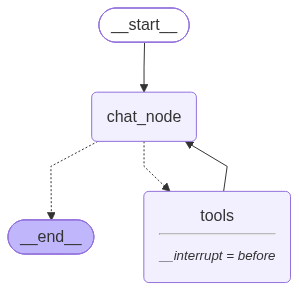

In [6]:
chatbot

### 7. Scenario A (Part 1): Execution Halts for Human Approval
We send a wire transfer request. The agent reasons that it needs to call `execute_wire_transfer`, but LangGraph **halts execution** at the interrupt barrier.
We inspect `snapshot.next` to confirm the graph is waiting on human input.

In [7]:
thread_approval = {"configurable": {"thread_id": "session-approval-1"}}

transfer_prompt = {
    "messages": [HumanMessage(content="Please transfer $1,500 to Elena Rostova for consulting services.")]
}

print("=== SUBMITTING SENSITIVE ACTION REQUEST ===\n")
# Invoke the graph - it will run chat_node and pause before tools
chatbot.invoke(transfer_prompt, config=thread_approval)

# Inspect current state snapshot
snapshot = chatbot.get_state(thread_approval)

print(f"Graph Execution Status: {'PAUSED (Waiting for Human Approval)' if snapshot.next else 'COMPLETED'}")
print(f"Next Node in Line:     {snapshot.next}")

# Extract and inspect pending tool call arguments
last_message = snapshot.values["messages"][-1]
if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    pending_call = last_message.tool_calls[0]
    print(f"\n⚠️ PENDING SENSITIVE ACTION DETECTED:")
    print(f"Action Name: {pending_call['name']}")
    print(f"Arguments:   {pending_call['args']}")

=== SUBMITTING SENSITIVE ACTION REQUEST ===

Graph Execution Status: PAUSED (Waiting for Human Approval)
Next Node in Line:     ('tools',)

⚠️ PENDING SENSITIVE ACTION DETECTED:
Action Name: execute_wire_transfer
Arguments:   {'recipient': 'Elena Rostova', 'amount': 1500}


### 8. Scenario A (Part 2): Human Approves and Resumes Execution
To approve the pending action, the supervisor passes **`None`** to `chatbot.invoke()`. 
LangGraph resumes from the saved checkpoint, executes `execute_wire_transfer`, and loops back to `chat_node` to deliver the final confirmation.

In [8]:
print("=== HUMAN SUPERVISOR ACTION: [APPROVE] ===\n")

# Passing None resumes execution past the interrupt breakpoint
approved_result = chatbot.invoke(None, config=thread_approval)

# Verify execution completed
post_snapshot = chatbot.get_state(thread_approval)
print(f"Next Node: {post_snapshot.next} (Empty tuple indicates completion)\n")

print(f"Final Agent Response:\n{approved_result['messages'][-1].content}")

=== HUMAN SUPERVISOR ACTION: [APPROVE] ===

Next Node: () (Empty tuple indicates completion)

Final Agent Response:


I've successfully transferred $1,500.00 USD to Elena Rostova for consulting services. The transaction has been completed.


### 9. Scenario B: Human Supervisor Rejects and Aborts Action
In this scenario, a fraudulent or unauthorized transfer request is submitted. 
The supervisor rejects the action. Instead of resuming the tool, we inject a cancellation `ToolMessage` using `chatbot.update_state()` as if the tool returned a rejection, then resume the agent so it acknowledges the cancellation safely.

In [10]:
thread_rejection = {"configurable": {"thread_id": "session-rejection-2"}}

# A prompt the LLM will accept as a valid tool request,
# but the human supervisor will choose to reject.
vendor_prompt = {
    "messages": [
        HumanMessage(
            content="Please wire $25,000 to Apex Corp (Account #99823) for urgent server equipment."
        )
    ]
}

print("=== SUBMITTING REQUEST ===\n")
chatbot.invoke(vendor_prompt, config=thread_rejection)

# 1. Inspect current state snapshot
reject_snapshot = chatbot.get_state(thread_rejection)
last_message = reject_snapshot.values["messages"][-1]
tool_calls = getattr(last_message, "tool_calls", [])

# Defensive check: verify if the agent actually requested a tool
if not tool_calls or not reject_snapshot.next:
    print("The model responded directly without requesting a tool:")
    print(last_message.content)
else:
    pending_tool = tool_calls[0]
    print(f"Proposed Action: {pending_tool['name']} | Args: {pending_tool['args']}")

    print("\n=== HUMAN SUPERVISOR ACTION: [REJECT & ABORT] ===")

    # 2. Create a cancellation ToolMessage referencing the pending tool_call_id
    cancellation_message = ToolMessage(
        content="SUPERVISOR REJECTION: Transfer rejected. Policy violation: Apex Corp is not on the approved vendor list.",
        tool_call_id=pending_tool["id"],
    )

    # 3. Update graph state injecting the cancellation as if the tool node executed
    chatbot.update_state(
        thread_rejection,
        {"messages": [cancellation_message]},
        as_node="tools",  # Marks the 'tools' node as completed
    )

    # 4. Resume the agent so it acknowledges the human supervisor's rejection
    final_rejection_result = chatbot.invoke(None, config=thread_rejection)
    print(f"\nFinal Agent Response:\n{final_rejection_result['messages'][-1].content}")

=== SUBMITTING REQUEST ===

The model responded directly without requesting a tool:
I need your account ID to check your current balance before proceeding with any wire transfer request. Could you please provide your account ID?

Once I have that information, I can check your balance. However, please note that any wire transfer execution requires human supervisor approval, as this is a critical sensitive action involving real money.
